# Trying to explain ML models using local explainers: SHAP and LIME

In this post I want to explain how SHAP and LIME techniques works using [Mobile Price Classification dataset](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification), creating a model to classify phone's price range and try to find an explanation about how models makes its predictions.

## SHAP
SHAP is a technique for explaining ML models using local instances, is based on game's theory of shapley's values. This technique is model agnostic, so it doesn't care what model are you traying to explain, it can calculate an approximate value of the feature's SHAP value.  
This method is based on the cooperative game's theory where the question was "how can I measure the contribution of each player to the final result of a match?", the same approach can be extrapolated to ML models, instead of players, we got data features.

### SHAP values
SHAP values are like the measure of contribution of some feature to a model prediction. SHAP values capture the marginal contribution of each feature to the final prediction. In other words, is the impact of having a certain for a value given feature in comparison to the prediction we'd make if that feature took some baseline value.

### How does it works?
Technique works creating an approximation of SHAP values based on some data, it takes actual model output and a baseline output following this equallity:

<center>
    $\sum_{shap_value \in SHAP_values} = model output - pred for baseline values$
</center>

to calculate baseline values it requires data instances, and the perfoms a calculation of a calculates a weighted mean average payoff gain that a single feature provides when included in all cases where is excluded, this is like asking "how many goals on average the team lose or win if a 'remove' Ronaldo or Messi in some soccer matches?".

### Procedure
1. Train ML model
2. Create a SHAP explainer instance for the model.
3. Calculate values SHAP values using **testing** or **validation datasets**.

4. Using those SHAP values, make some plots like a force plot, a summary plot or a dependence contribution plot.

In [56]:
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

data = read_csv("/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv")

COL_MAPPER = {"fc": "front_camera_pixels", "four_g": "has_4g", "int_memory": "storage_size", 
              "mobile_wt": "weight", "m_dep": "depth_cm", "n_cores": "cpu_cores", "pc": "rear_camera_pixels",
              "px_width": "screen_width_pixels", "px_height": "screen_height_pixels", "sc_w": "screen_width_cm",
              "sc_h": "screen_height_cm", "three_g": "has_3g", "touch_screen": "has_touch_screen", "wifi": "has_wifi",
              "blue": "has_bluetooth", "clock_speed": "cpu_clock_speed"}

train_data = data.rename(columns=COL_MAPPER)

In [42]:
data["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [61]:
NUMS = ["battery_power","cpu_clock_speed", "depth_cm", "front_camera_pixels", "storage_size", "weight", "cpu_cores",
       "rear_camera_pixels", "screen_height_pixels","screen_width_pixels","ram","screen_height_cm","screen_width_cm","talk_time"]
BINS = ["has_4g", "has_3g", "has_bluetooth", "dual_sim", "has_wifi", "has_touch_screen"]
FEATURES = NUMS + BINS
TAG = "price_range"

train_data, test_data = train_test_split(train_data, train_size=0.8, test_size=0.2, random_state=123)

x_train, y_train = train_data[FEATURES], train_data[TAG]
x_test, y_test = test_data[FEATURES], test_data[TAG]

TRANSFORMER = ColumnTransformer([
    ("normalized", StandardScaler(), NUMS),
], remainder="passthrough", verbose_feature_names_out=False)

TRANSFORMER.set_output(transform="pandas")

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

MODEL = RandomForestClassifier(random_state=123, n_estimators=3, max_depth=8, criterion="gini")
MODEL.fit(X_train, y_train)
y_pred = MODEL.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1Score = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {(accuracy*100):2f} %")
print(f"Weighted F1-Score: {(f1Score*100):2f} %")

Accuracy: 70.121951 %
Weighted F1-Score: 70.225352 %


So, the classifier is trained and ready to be used on `shap` library, so this is a multiclass problem, then SHAP values area going to be calculated for every class.  
We are using a random forest classifier, so we must use ´TreeExplainer´ from `shap` library, we must pass the model and test dataset.

In [62]:
from shap import TreeExplainer, initjs, force_plot

shap_explainer = TreeExplainer(MODEL)
shap_values = shap_explainer.shap_values(X_test, y_test)

Explainer model will have an expected/baseline value for each class

In [ ]:
initjs()

In [81]:
shap_xd = shap_explainer(X_test, y_test)

<class 'shap._explanation.Explanation'>


In [96]:
# First dimension is the row instance
# Second are the features
# Third are the classes
shap_values.shape

(164, 20, 4)

## Violin plot (previously summary plot)
Shows the significance of feature values due to models classification for each instances. Each dot is a row instance, color represents the feature value, y-axis is the regarding feature and x-axis is the respective SHAP value. **This plot is designed to be used on dataset, not just in a single instance**.

In this case, positive SHAP values tell us how  much each feature contributes to classify an instance in this class. For example, in the following chart, "ram" feature has been taken as the most important feature. Watching its values, we can detail that mobile phones with too small ram sizes are classified into the cheapest price category ('Category 0')and higher values are predicted in more expensive classes.

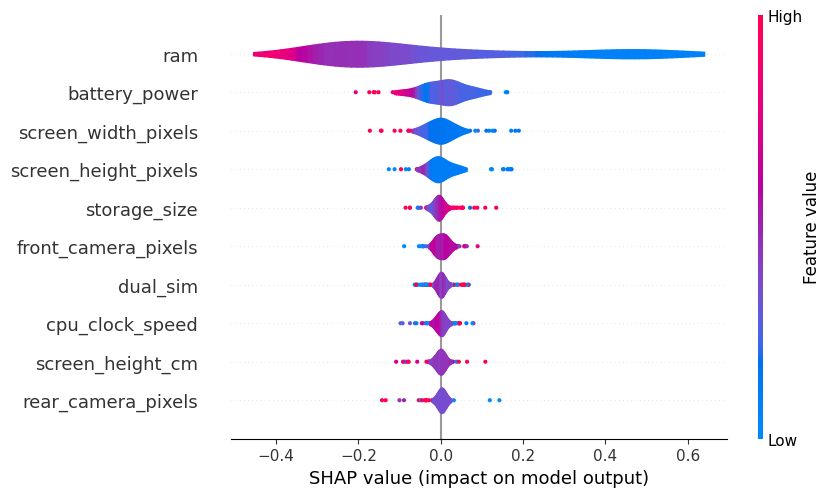

In [112]:
from shap.plots import violin

plot = violin(shap_values[:, :, 0], X_test, max_display=10)

### Force plot

In [71]:

force_plot(shap_explainer.expected_value[0], shap_values[0], .value)